In [ ]:
import kagglehub
import os

# Download latest version
base_path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

# Adjust path to point to the actual data directory
path = os.path.join(base_path, 'Data')

print("Path to dataset files:", path)

100%|██████████| 17.7M/17.7M [00:00<00:00, 137MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ksir0423/stationery-dataset-1/versions/1/Data


In [ ]:
import tensorflow as tf

# Check for GPU activity
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Number of GPUs available: {len(gpus)}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU found: {gpu}")
else:
    print("No GPU devices found. Training will run on CPU.")

print(f"TensorFlow version: {tf.__version__}")

Number of GPUs available: 1
GPU found: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow version: 2.20.0


In [ ]:
import tensorflow as tf

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Load and preprocess the dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Get the number of classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1774 files belonging to 2 classes.
Using 1420 files for training.
Found 1774 files belonging to 2 classes.
Using 354 files for validation.
Number of classes: 2
Class names: ['Test', 'Train']


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of VGG16
x = base_model.output
x = Flatten()(x) # Flatten the output from the convolutional layers
x = Dense(256, activation='relu')(x) # Add a fully connected layer with ReLU activation
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax for classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Now, let's compile the model and train it using the prepared image dataset. We'll use the Adam optimizer and sparse categorical crossentropy as the loss function since our labels are integers.

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train the model
EPOCHS = 10 # You can adjust the number of epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 395ms/step - accuracy: 0.6232 - loss: 9.9282 - val_accuracy: 0.6073 - val_loss: 1.8878
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.7317 - loss: 0.7037 - val_accuracy: 0.7119 - val_loss: 0.8449
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.7761 - loss: 0.4992 - val_accuracy: 0.7486 - val_loss: 0.7827
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.7725 - loss: 0.4485 - val_accuracy: 0.7542 - val_loss: 0.8389
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.7768 - loss: 0.4016 - val_accuracy: 0.6949 - val_loss: 0.8368
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.7993 - loss: 0.3789 - val_accuracy: 0.6921 - val_loss: 0.8974
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.8049 - loss: 0.3699 - val_accuracy: 0.6469 - val_loss: 0.8912
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.8155 - loss: 0.3470 - val_accuracy: 0

The model has finished training. Let's summarize the training results, showing the final accuracy and loss on both the training and validation datasets.

In [ ]:
# Summarize training results

# Get final training and validation metrics
final_train_loss = history.history['loss'][-1]
final_train_accuracy = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"\n--- Training Summary ---")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")


--- Training Summary ---
Final Training Loss: 0.3305
Final Training Accuracy: 0.8176
Final Validation Loss: 1.0701
Final Validation Accuracy: 0.6497


Finally, let's visualize the training and validation accuracy and loss over epochs to understand the model's learning progress.

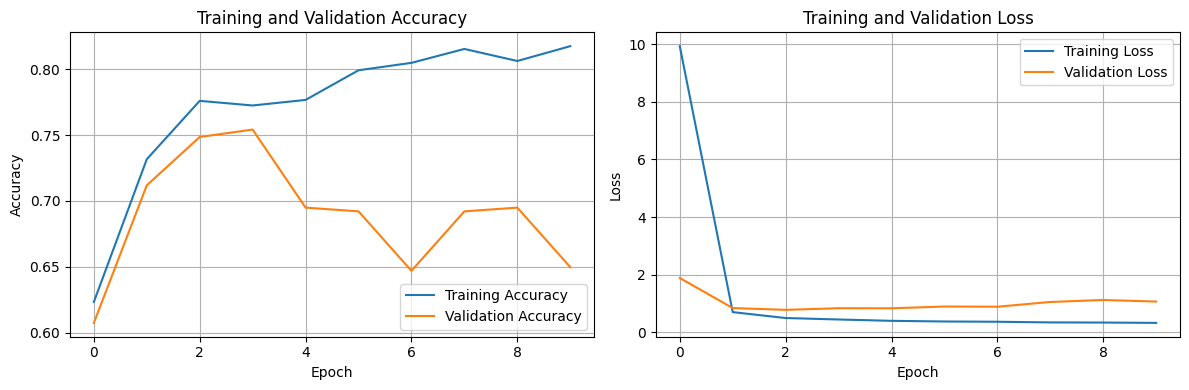

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()